# CS-573 Project Implementation
---
- Iliana Platona (csdp1436)
- Charalampos Apostolou (csdp1415)
---

### 0. Import Libraries

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

### 1. Shared Data Pipeline

In [2]:
def load_and_split_data():
  # Load Sataset.
  ratings = pd.read_csv('ratings.csv')

  # Map IDs.
  user_map = {u: i for i, u in enumerate(ratings['userId'].unique())}
  item_map = {m: i for i, m in enumerate(ratings['movieId'].unique())}

  ratings['user_idx'] = ratings['userId'].map(user_map)
  ratings['movie_idx'] = ratings['movieId'].map(item_map)

  n_users, n_items = len(user_map), len(item_map)

  # Shared Split.
  train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

  # Matrix for ALS.
  M_train = np.zeros((n_users, n_items))
  mask_train = np.zeros((n_users, n_items), dtype=bool)

  for row in train_df.itertuples():
    M_train[row.user_idx, row.movie_idx] = row.rating
    mask_train[row.user_idx, row.movie_idx] = True

  # Print Results.
  print(f"Data Prepared: {n_users} Users, {n_items} Items")
  print(f"Train Size: {len(train_df)}, Test Size: {len(test_df)}")

  return train_df, test_df, M_train, mask_train, n_users, n_items

In [3]:
def evaluate_model(model_name, true_ratings, predictions, duration):
  # Both models must be clipped [0.5, 5.0]
  pred_clipped = np.clip(predictions, 0.5, 5.0)

  mse = np.mean((true_ratings - pred_clipped) ** 2)
  rmse = np.sqrt(mse)

  print(f"[{model_name}] RMSE: {rmse:.4f} | Time: {duration:.2f}s")

  return rmse

### 2. ALS Implementation.

In [4]:
def compute_biases_damped(M, mask, lambda_reg=25.0):
  mask = mask.astype(bool)

  global_mean = np.sum(M[mask]) / np.sum(mask)
  n_users, n_items = M.shape

  b_i = np.zeros(n_items)
  for i in range(n_items):
    idx = mask[:, i]
    if idx.sum() > 0:
      b_i[i] = np.sum(M[idx, i] - global_mean) / (idx.sum() + lambda_reg)

  b_u = np.zeros(n_users)
  for u in range(n_users):
    idx = mask[u, :]
    if idx.sum() > 0:
      b_u[u] = np.sum(M[u, idx] - global_mean - b_i[idx]) / (idx.sum() + lambda_reg)

  return global_mean, b_u, b_i

In [5]:
def run_als(M_train, mask_train, test_df, n_users, n_items):
  start = time.time()

  # Hyperparams (from your successful run)
  rank = 70
  lambda_als = 10.0
  lambda_bias = 10.0
  iterations = 15

  # 1. Compute Biases
  mu, b_u, b_i = compute_biases_damped(M_train, mask_train, lambda_reg=lambda_bias)

  # 2. Compute Residuals
  M_resid = np.zeros_like(M_train)
  rows, cols = np.where(mask_train)
  for r, c in zip(rows, cols):
    M_resid[r, c] = M_train[r, c] - (mu + b_u[r] + b_i[c])

  # 3. Train Factors
  U = np.random.normal(scale=1./rank, size=(n_users, rank))
  V = np.random.normal(scale=1./rank, size=(n_items, rank))
  lambda_I = lambda_als * np.eye(rank)
  rmses = []
  for _ in range(iterations):
    # Update U
    VtV = np.dot(V.T, V)
    for i in range(n_users):
      idx = mask_train[i, :] == 1
      if idx.sum() > 0:
        V_sub = V[idx, :]
        A = np.dot(V_sub.T, V_sub) + lambda_I
        b = np.dot(V_sub.T, M_resid[i, idx])
        U[i, :] = np.linalg.solve(A, b)
    # Update V
    for j in range(n_items):
      idx = mask_train[:, j] == 1
      if idx.sum() > 0:
        U_sub = U[idx, :]
        A = np.dot(U_sub.T, U_sub) + lambda_I
        b = np.dot(U_sub.T, M_resid[idx, j])
        V[j, :] = np.linalg.solve(A, b)

  # 4. Predict on Test Set
  test_users = test_df['user_idx'].values
  test_items = test_df['movie_idx'].values
  true_ratings = test_df['rating'].values

  # Vectorized prediction
  # Pred = mu + bu + bi + u.v
  # (Using simple loop to avoid memory issues with massive broadcasting)
  preds = []
  for u, i in zip(test_users, test_items):
    pred = mu + b_u[u] + b_i[i] + np.dot(U[u], V[i])
    preds.append(pred)

  return evaluate_model("ALS (Damped)", true_ratings, np.array(preds), time.time() - start)

In [6]:
def run_sgd_improved(train_df, test_df, n_users, n_items):
  start = time.time()

  # Improvement 1: Hyperparameters
  K = 70
  alpha = 0.02        # Higher start rate
  decay = 0.02        # Decay factor
  lambda_reg = 0.05   # Stronger regularization
  epochs = 30         # More epochs (SGD needs time)

  # Init
  mu = train_df['rating'].mean()
  b_u = np.zeros(n_users)
  b_i = np.zeros(n_items)
  P = np.random.normal(scale=1./K, size=(n_users, K))
  Q = np.random.normal(scale=1./K, size=(n_items, K))

  users = train_df['user_idx'].values
  items = train_df['movie_idx'].values
  ratings = train_df['rating'].values
  n_samples = len(users)
  indices = np.arange(n_samples)

  print(f"Training SGD (Alpha={alpha}, Decay={decay})...")

  for epoch in range(epochs):
    # Improvement 2: Learning Rate Decay
    current_alpha = alpha / (1 + decay * epoch)
    np.random.shuffle(indices)

    for idx in indices:
      u, i, r = users[idx], items[idx], ratings[idx]
      dot = np.dot(P[u], Q[i])
      pred = mu + b_u[u] + b_i[i] + dot
      err = r - pred

      # Improvement 3: Update Biases WITH Regularization
      b_u[u] += current_alpha * (err - lambda_reg * b_u[u])
      b_i[i] += current_alpha * (err - lambda_reg * b_i[i])

      # Update Factors
      p_old = P[u].copy()
      P[u] += current_alpha * (err * Q[i] - lambda_reg * P[u])
      Q[i] += current_alpha * (err * p_old - lambda_reg * Q[i])

  # Predict
  test_users = test_df['user_idx'].values
  test_items = test_df['movie_idx'].values
  true_ratings = test_df['rating'].values

  preds = []
  for u, i in zip(test_users, test_items):
    pred = mu + b_u[u] + b_i[i] + np.dot(P[u], Q[i])
    preds.append(pred)

  return evaluate_model("SGD (Improved)", true_ratings, np.array(preds), time.time() - start)

### 4. Execution

In [7]:
# 1. Prep
print("--- Loading and Splitting Data ---")
train_df, test_df, M_train, mask_train, n_users, n_items = load_and_split_data()

# 2. Run Apples-to-Apples
print("\n--- Starting Comparison ---")
rmse_als = run_als(M_train, mask_train, test_df, n_users, n_items)
rmse_sgd = run_sgd_improved(train_df, test_df, n_users, n_items)

print("\n--- Verdict ---")
diff = rmse_sgd - rmse_als
print(f"Gap: {diff:.4f}")
print(f"RMSE ALS: {rmse_als:.4f} | RMSE SGD: {rmse_sgd:.4f}")
if abs(diff) < 0.01:
  print("Result: EFFECTIVELY TIED (Differences are negligible)")
elif diff > 0:
  print("Result: ALS WINS (Likely due to Damped Bias pre-calculation)")
else:
  print("Result: SGD WINS")

--- Loading and Splitting Data ---
Data Prepared: 610 Users, 9724 Items
Train Size: 80668, Test Size: 20168

--- Starting Comparison ---
[ALS (Damped)] RMSE: 0.8595 | Time: 25.36s
Training SGD (Alpha=0.02, Decay=0.02)...
[SGD (Improved)] RMSE: 0.8534 | Time: 46.85s

--- Verdict ---
Gap: -0.0062
RMSE ALS: 0.8595 | RMSE SGD: 0.8534
Result: EFFECTIVELY TIED (Differences are negligible)


## Second Script.

### 1. Shared Data Pipeline

In [8]:
# def load_and_split_data(): (implemented before)
def get_rmse_vectorized(true_ratings, preds):
  # Vectorized RMSE calculation for speed
  preds_clipped = np.clip(preds, 0.5, 5.0)

  return np.sqrt(np.mean((true_ratings - preds_clipped)**2))

### 2. Smart Alternate Least Squares (History Tracking)

In [9]:
def run_smart_als_history(M, mask, test_df, n_users, n_items, rank=12, reg=10.0, bias_reg=25.0, iters=15):
  history = []

  # A. Pre-calculate Damped Biases
  global_mean = M[mask].mean()
  b_i = np.zeros(n_items)
  b_u = np.zeros(n_users)

  # Vectorized Bias Calc
  # (Doing this inside loop for clarity, but logic is "smart")
  for i in range(n_items):
    idx = mask[:, i]
    if idx.sum() > 0:
      b_i[i] = np.sum(M[idx, i] - global_mean) / (idx.sum() + bias_reg)
  for u in range(n_users):
    idx = mask[u, :]
    if idx.sum() > 0:
      b_u[u] = np.sum(M[u, idx] - global_mean - b_i[idx]) / (idx.sum() + bias_reg)

  # B. Calculate Residuals
  M_resid = np.zeros_like(M)
  rows, cols = np.where(mask)
  for r, c in zip(rows, cols):
    M_resid[r, c] = M[r, c] - (global_mean + b_u[r] + b_i[c])

  # C. ALS Loop
  U = np.random.normal(scale=1./rank, size=(n_users, rank))
  V = np.random.normal(scale=1./rank, size=(n_items, rank))
  lambda_I = reg * np.eye(rank)

  # Pre-extract Test Arrays for Fast Scoring
  test_u_idx = test_df['user_idx'].values
  test_i_idx = test_df['movie_idx'].values
  test_y_true = test_df['rating'].values

  print("Training Smart ALS...")
  for it in range(iters):
    # Update U
    VtV = np.dot(V.T, V)
    for i in range(n_users):
      idx = mask[i, :]
      if idx.sum() > 0:
        V_sub = V[idx, :]
        A = np.dot(V_sub.T, V_sub) + lambda_I
        b = np.dot(V_sub.T, M_resid[i, idx])
        U[i, :] = np.linalg.solve(A, b)

    # Update V
    for j in range(n_items):
      idx = mask[:, j]
      if idx.sum() > 0:
        U_sub = U[idx, :]
        A = np.dot(U_sub.T, U_sub) + lambda_I
        b = np.dot(U_sub.T, M_resid[idx, j])
        V[j, :] = np.linalg.solve(A, b)

    # Fast Score at end of iteration
    # Prediction = mu + bu + bi + (U . V)
    interaction = np.sum(U[test_u_idx] * V[test_i_idx], axis=1)
    preds = global_mean + b_u[test_u_idx] + b_i[test_i_idx] + interaction
    rmse = get_rmse_vectorized(test_y_true, preds)
    history.append(rmse)
    print(f"  ALS Iter {it+1}: {rmse:.4f}")

  return history

### 3. Smart Stochastic Gradient Descent (History Tracking)

In [10]:
def run_smart_sgd_history(train_df, test_df, n_users, n_items, rank=12, lr=0.02, reg=0.1, decay=0.02, epochs=30):
  history = []

  # Init
  mu = train_df['rating'].mean()
  b_u = np.zeros(n_users)
  b_i = np.zeros(n_items)
  P = np.random.normal(scale=1./rank, size=(n_users, rank))
  Q = np.random.normal(scale=1./rank, size=(n_items, rank))

  # Pre-extract Arrays
  u_vec = train_df['user_idx'].values
  i_vec = train_df['movie_idx'].values
  r_vec = train_df['rating'].values
  indices = np.arange(len(u_vec))

  test_u_idx = test_df['user_idx'].values
  test_i_idx = test_df['movie_idx'].values
  test_y_true = test_df['rating'].values

  print("Training Smart SGD...")
  for epoch in range(epochs):
    # Decay Learning Rate
    current_lr = lr / (1 + decay * epoch)
    np.random.shuffle(indices)

    # Fast Loop (Optimized somewhat)
    for idx in indices:
      u, i, r = u_vec[idx], i_vec[idx], r_vec[idx]

      dot = np.dot(P[u], Q[i])
      pred = mu + b_u[u] + b_i[i] + dot
      err = r - pred

      # Update Biases (Regularized)
      b_u[u] += current_lr * (err - reg * b_u[u])
      b_i[i] += current_lr * (err - reg * b_i[i])

      # Update Factors (Regularized)
      p_old = P[u].copy()
      P[u] += current_lr * (err * Q[i] - reg * P[u])
      Q[i] += current_lr * (err * p_old - reg * Q[i])

    # Fast Score at end of epoch
    interaction = np.sum(P[test_u_idx] * Q[test_i_idx], axis=1)
    preds = mu + b_u[test_u_idx] + b_i[test_i_idx] + interaction
    rmse = get_rmse_vectorized(test_y_true, preds)
    history.append(rmse)
    print(f"  SGD Epoch {epoch+1}: {rmse:.4f}")

  return history

### 4. Plotting

Data Prepared: 610 Users, 9724 Items
Train Size: 80668, Test Size: 20168
Training Smart ALS...
  ALS Iter 1: 0.8819
  ALS Iter 2: 0.8718
  ALS Iter 3: 0.8642
  ALS Iter 4: 0.8633
  ALS Iter 5: 0.8631
  ALS Iter 6: 0.8629
  ALS Iter 7: 0.8627
  ALS Iter 8: 0.8625
  ALS Iter 9: 0.8623
  ALS Iter 10: 0.8622
  ALS Iter 11: 0.8621
  ALS Iter 12: 0.8620
  ALS Iter 13: 0.8619
  ALS Iter 14: 0.8618
  ALS Iter 15: 0.8618
  ALS Iter 16: 0.8617
  ALS Iter 17: 0.8616
  ALS Iter 18: 0.8616
  ALS Iter 19: 0.8616
  ALS Iter 20: 0.8615
  ALS Iter 21: 0.8615
  ALS Iter 22: 0.8615
  ALS Iter 23: 0.8614
  ALS Iter 24: 0.8614
  ALS Iter 25: 0.8614
  ALS Iter 26: 0.8614
  ALS Iter 27: 0.8614
  ALS Iter 28: 0.8613
  ALS Iter 29: 0.8613
  ALS Iter 30: 0.8613
Training Smart SGD...
  SGD Epoch 1: 0.9057
  SGD Epoch 2: 0.8924
  SGD Epoch 3: 0.8878
  SGD Epoch 4: 0.8843
  SGD Epoch 5: 0.8813
  SGD Epoch 6: 0.8802
  SGD Epoch 7: 0.8789
  SGD Epoch 8: 0.8780
  SGD Epoch 9: 0.8762
  SGD Epoch 10: 0.8755
  SGD Epoch

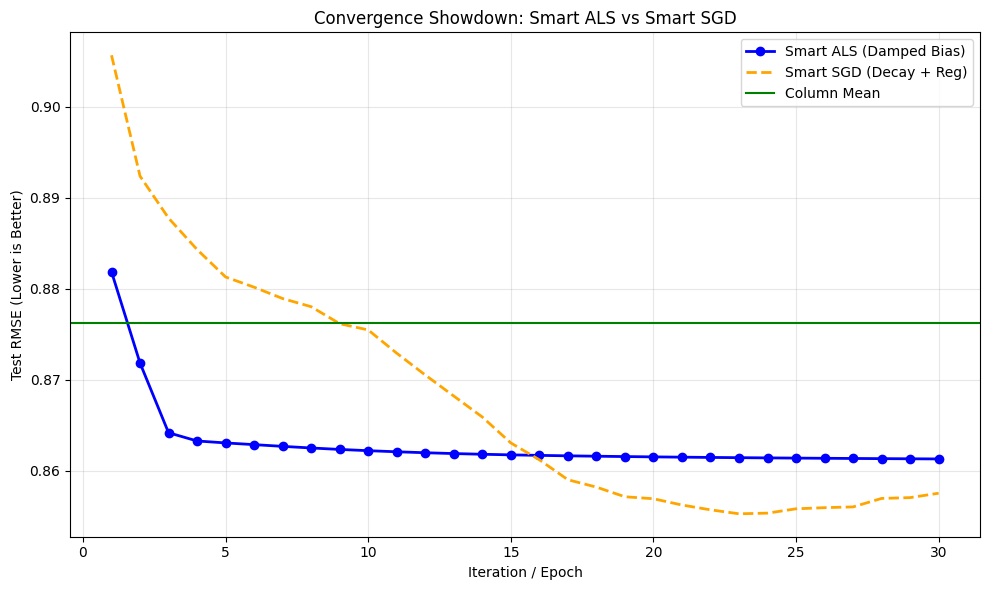

In [11]:
# 1. Prep
train_df, test_df, M, mask, n_users, n_items = load_and_split_data()
iterations = 30

# 2. Run Smart Models
# Note: SGD needs more epochs (30) to catch up to ALS (15)
als_hist = run_smart_als_history(M, mask, test_df, n_users, n_items,
                                    rank=50, reg=10.0, bias_reg=10.0, iters=iterations)

sgd_hist = run_smart_sgd_history(train_df, test_df, n_users, n_items,
                                    rank=50, lr=0.02, reg=0.05, decay=0.02, epochs=iterations)

# 3. Plot
plt.figure(figsize=(10, 6))

# Plot ALS
plt.plot(range(1, len(als_hist)+1), als_hist,
            label='Smart ALS (Damped Bias)', color='blue', linewidth=2, marker='o')

# Plot SGD
plt.plot(range(1, len(sgd_hist)+1), sgd_hist,
            label='Smart SGD (Decay + Reg)', color='orange', linewidth=2, linestyle='--')
plt.axhline(0.8762, color='green', linestyle='-', linewidth=1.5, label = 'Column Mean')
plt.title("Convergence Showdown: Smart ALS vs Smart SGD")
plt.xlabel("Iteration / Epoch")
plt.ylabel("Test RMSE (Lower is Better)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# plt.savefig("smartplot.png")